In [152]:
# 1) Création du venv
!python -m venv .venv

# 2) Installation des libs dans le venv via le pip du venv
!.venv\Scripts\python -m pip install --upgrade pip
!.venv\Scripts\pip install -r requirements.txt

# 🏢 Projet ML - Système de Prédiction RH

Ce notebook implémente un système complet de comparaison de modèles ML pour prédire l'attrition des employés (départ de l'entreprise).

## 📋 Contenu
1. **Prétraitement des données** - Extraction et fusion des fichiers CSV
2. **Chargement et préparation des données**
3. **Définition des modèles**
4. **Réglage des hyperparamètres (optionnel)**
5. **Entraînement et évaluation**
6. **Comparaison des modèles**
7. **Validation croisée**

## 🔧 ÉTAPE 0 - Prétraitement des Données Brutes

### Extraction du fichier ZIP

Les données sont dans un fichier `in_out_time.zip` qui contient plusieurs fichiers CSV.

In [153]:
import shutil
import os

data_root="data/"

# Extraire le fichier ZIP s'il existe
if os.path.exists(data_root + 'in_out_time.zip'):
    print("📦 Extraction du fichier in_out_time.zip...")
    shutil.unpack_archive(data_root + 'in_out_time.zip', data_root)
    print("✅ Extraction terminée")
else:
    print("⚠️ Le fichier in_out_time.zip n'existe pas. Vérifiez que les fichiers CSV sont déjà extraits.")

📦 Extraction du fichier in_out_time.zip...
✅ Extraction terminée


### Fusion des fichiers CSV

Les données RH sont réparties dans 5 fichiers différents :
- `general_data.csv` - Données générales des employés
- `employee_survey_data.csv` - Enquête auprès des employés
- `manager_survey_data.csv` - Enquête auprès des managers
- `in_time.csv` - Heures d'arrivée
- `out_time.csv` - Heures de départ

Nous allons les fusionner via l'`EmployeeID`.

In [154]:
import pandas as pd
import glob

# Vérifier la présence des fichiers
required_files = [data_root + 'general_data.csv', data_root + 'employee_survey_data.csv', data_root + 'manager_survey_data.csv', 
                  data_root + 'in_time.csv', data_root + 'out_time.csv']
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    print(f"❌ Fichiers manquants: {missing_files}")
    print("⚠️ Assurez-vous d'avoir extrait le fichier ZIP ou que les CSV sont présents.")
else:
    print("📊 Chargement des fichiers CSV...")
    
    # Charger les fichiers principaux
    df1 = pd.read_csv(data_root + 'general_data.csv')
    df2 = pd.read_csv(data_root + 'employee_survey_data.csv')
    df3 = pd.read_csv(data_root + 'manager_survey_data.csv')
    
    print(f"  - general_data.csv: {df1.shape}")
    print(f"  - employee_survey_data.csv: {df2.shape}")
    print(f"  - manager_survey_data.csv: {df3.shape}")
    
    # Charger les fichiers temporels
    df4 = pd.read_csv(data_root + 'in_time.csv')
    df5 = pd.read_csv(data_root + 'out_time.csv')
    
    print(f"  - in_time.csv: {df4.shape}")
    print(f"  - out_time.csv: {df5.shape}")
    
    # Renommer la première colonne des fichiers in/out time
    df4 = df4.rename(columns={'Unnamed: 0': 'EmployeeID'})
    df5 = df5.rename(columns={'Unnamed: 0': 'EmployeeID'})
    
    print("\n🔧 Création de features agrégées à partir des données temporelles...")
    print("   (Pour éviter l'explosion de mémoire avec 1M+ colonnes)")
    
    # Créer des features agrégées au lieu d'utiliser toutes les colonnes de dates
    def create_time_features(df_time, prefix='in'):
        """Créer des features agrégées à partir des heures d'arrivée/départ"""
        # Sélectionner seulement les colonnes de dates (pas EmployeeID)
        date_cols = [col for col in df_time.columns if col != 'EmployeeID']
        
        # Convertir en format datetime
        df_values = df_time[date_cols].apply(pd.to_datetime, errors='coerce')
        
        # Extraire l'heure en format numérique (heures + minutes/60)
        df_hours = df_values.apply(lambda x: x.dt.hour + x.dt.minute/60.0)
        
        # Calculer des statistiques agrégées
        features = pd.DataFrame()
        features['EmployeeID'] = df_time['EmployeeID']
        features[f'{prefix}_avg_hour'] = df_hours.mean(axis=1)  # Heure moyenne
        features[f'{prefix}_std_hour'] = df_hours.std(axis=1)   # Variabilité
        features[f'{prefix}_min_hour'] = df_hours.min(axis=1)   # Plus tôt
        features[f'{prefix}_max_hour'] = df_hours.max(axis=1)   # Plus tard
        features[f'{prefix}_missing_days'] = df_values.isna().sum(axis=1)  # Jours manquants
        
        return features
    
    # Créer les features pour in_time et out_time
    in_features = create_time_features(df4, prefix='arrival')
    out_features = create_time_features(df5, prefix='departure')
    
    # Fusionner les features temporelles
    time_features = in_features.merge(out_features, on='EmployeeID', how='inner')
    
    # Calculer le temps de travail moyen
    time_features['avg_work_hours'] = (
        time_features['departure_avg_hour'] - time_features['arrival_avg_hour']
    )
    
    print(f"  - Features temporelles créées: {time_features.shape[1]-1} colonnes")
    
    print("\n🔗 Fusion des données...")
    # Fusion en chaîne (2 par 2)
    resultat = df1.merge(df2, on='EmployeeID', how='inner') \
                  .merge(df3, on='EmployeeID', how='inner') \
                  .merge(time_features, on='EmployeeID', how='inner')
    
    # Suppression des colonnes inutiles
    colonnes_a_supprimer = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']
    colonnes_existantes = [col for col in colonnes_a_supprimer if col in resultat.columns]
    
    if colonnes_existantes:
        resultat = resultat.drop(colonnes_existantes, axis=1)
        print(f"  - Colonnes supprimées: {colonnes_existantes}")
    
    # Sauvegarder
    resultat.to_csv('Dataset_clean.csv', index=False)
    
    print(f"\n✅ Dataset fusionné et sauvegardé dans 'Dataset_clean.csv'")
    print(f"   Dimensions: {resultat.shape[0]} lignes × {resultat.shape[1]} colonnes")
    print(f"\n📋 Aperçu des colonnes:")
    print(f"   Colonnes générales: {list(df1.columns[:5])}...")
    print(f"   Features temporelles: {list(time_features.columns[1:6])}...")
    
    # Afficher les premières lignes
    print(f"\n📊 Aperçu des données:")
    display(resultat.head())
    
    # Vérifier les valeurs manquantes
    print(f"\n🔍 Valeurs manquantes par colonne:")
    missing = resultat.isnull().sum()
    if missing.sum() > 0:
        display(missing[missing > 0])
    else:
        print("   Aucune valeur manquante !")

📊 Chargement des fichiers CSV...
  - general_data.csv: (4410, 24)
  - employee_survey_data.csv: (4410, 4)
  - manager_survey_data.csv: (4410, 3)
  - in_time.csv: (4410, 262)
  - out_time.csv: (4410, 262)

🔧 Création de features agrégées à partir des données temporelles...
   (Pour éviter l'explosion de mémoire avec 1M+ colonnes)
  - Features temporelles créées: 11 colonnes

🔗 Fusion des données...
  - Colonnes supprimées: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']

✅ Dataset fusionné et sauvegardé dans 'Dataset_clean.csv'
   Dimensions: 4410 lignes × 36 colonnes

📋 Aperçu des colonnes:
   Colonnes générales: ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome']...
   Features temporelles: ['arrival_avg_hour', 'arrival_std_hour', 'arrival_min_hour', 'arrival_max_hour', 'arrival_missing_days']...

📊 Aperçu des données:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,...,arrival_std_hour,arrival_min_hour,arrival_max_hour,arrival_missing_days,departure_avg_hour,departure_std_hour,departure_min_hour,departure_max_hour,departure_missing_days,avg_work_hours
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,Female,1,Healthcare Representative,...,0.258456,9.216667,10.616667,29,17.367170,0.373791,16.300000,18.233333,29,7.374138
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,Female,1,Research Scientist,...,0.293095,9.200000,10.716667,25,17.698446,0.418810,16.450000,18.816667,25,7.717726
2,32,No,Travel_Frequently,Research & Development,17,4,Other,Male,4,Sales Executive,...,0.272513,9.133333,10.866667,19,17.030096,0.395190,15.966667,18.116667,19,7.013499
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,Male,3,Human Resources,...,0.282750,9.200000,10.833333,26,17.167305,0.407105,16.033333,18.166667,26,7.193475
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,Male,1,Sales Executive,...,0.270862,9.300000,10.900000,16,17.996327,0.405745,16.883333,19.366667,16,8.006259



🔍 Valeurs manquantes par colonne:


NumCompaniesWorked         19
TotalWorkingYears           9
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
dtype: int64

## 2️⃣ Chargement et Préparation des Données

Nous allons utiliser le fichier `Dataset_clean.csv` créé lors du prétraitement.

In [155]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

# Métriques
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, confusion_matrix, 
    roc_curve, precision_recall_curve, average_precision_score
)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Imports terminés")

✅ Imports terminés


## 1️⃣ Imports et Configuration

In [156]:
def get_data_pipeline(csv_path, target_column='Attrition'):
    """
    Créer le pipeline de chargement et prétraitement des données avec split 70/15/15:
    1. Remplir les valeurs manquantes (médiane pour numérique, mode pour catégoriel)
    2. Transformer les données catégorielles avec OneHotEncoder
    3. Standardisation
    4. Split en 3 ensembles : Train (70%), Validation (15%), Test (15%)
    
    Args:
        csv_path: chemin vers le fichier CSV
        target_column: nom de la colonne cible (par défaut 'Attrition')
    """
    print(f"[Loader] Chargement des données depuis: {csv_path}")
    
    # 1. CHARGER LES DONNÉES
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
    except FileNotFoundError:
        raise FileNotFoundError(f"Fichier introuvable: {csv_path}")

    print(f"[Loader] Dataset chargé: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    
    # Vérifier si la colonne cible existe
    if target_column not in df.columns:
        print(f"\n⚠️ La colonne '{target_column}' n'existe pas.")
        print(f"📋 Colonnes disponibles: {list(df.columns[:20])}")
        raise ValueError(f"Colonne cible '{target_column}' introuvable dans le dataset")
    
    # Séparer features X et target y
    blacklist = []  # Liste pour éviter les fuites de données si nécessaire
    cols_to_drop = [c for c in blacklist if c in df.columns]
    
    if cols_to_drop:
        df = df.drop(cols_to_drop, axis=1)
        print(f"[Loader] Colonnes supprimées: {cols_to_drop}")
    
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    # Convertir la cible en format binaire si nécessaire (Yes/No -> 1/0)
    if y.dtype == 'object':
        print(f"[Loader] Conversion de la variable cible en format binaire")
        y = y.map({'Yes': 1, 'No': 0})
        if y.isnull().any():
            print(f"⚠️ Valeurs non converties détectées dans la cible")

    # 2. SPLIT 70/15/15 (train/validation/test)
    print(f"\n[Loader] Split des données: 70% Train / 15% Validation / 15% Test")
    
    # Premier split : 70% train, 30% temp (validation + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    
    # Deuxième split : diviser les 30% en 15% validation et 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    # 3. PIPELINE DE PRÉTRAITEMENT
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_features = X.select_dtypes(include=['object']).columns.tolist()
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    
    print(f"[Loader] Features numériques: {len(numeric_features)}")
    print(f"[Loader] Features catégorielles: {len(categorical_features)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, preprocessor

print("✅ Fonction de chargement définie (split 70/15/15)")

✅ Fonction de chargement définie (split 70/15/15)


In [157]:
# Charger les données avec split 70/15/15
print("🔄 Chargement des données RH...\n")

# Vérifier si le fichier existe
if not os.path.exists("Dataset_clean.csv"):
    print("❌ Le fichier 'Dataset_clean.csv' n'existe pas.")
    print("⚠️ Veuillez exécuter les cellules de prétraitement ci-dessus d'abord.")
    raise FileNotFoundError("Dataset_clean.csv introuvable. Exécutez d'abord le prétraitement.")

# Charger avec la colonne cible appropriée (Attrition pour les données RH)
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = get_data_pipeline(
    "Dataset_clean.csv", 
    target_column='Attrition'  # Changez si votre colonne cible a un autre nom
)

print(f"\n📊 Dimensions des données (70/15/15):")
print(f"   - Train:      X={X_train.shape}, y={y_train.shape}")
print(f"   - Validation: X={X_val.shape}, y={y_val.shape}")
print(f"   - Test:       X={X_test.shape}, y={y_test.shape}")

# Afficher la distribution de la target
print(f"\n🎯 Distribution de la variable cible:")
print(f"\n📊 Train set:")
display(pd.DataFrame({
    'Count': y_train.value_counts(),
    'Proportion': y_train.value_counts(normalize=True)
}))

print(f"\n📊 Validation set:")
display(pd.DataFrame({
    'Count': y_val.value_counts(),
    'Proportion': y_val.value_counts(normalize=True)
}))

print(f"\n📊 Test set:")
display(pd.DataFrame({
    'Count': y_test.value_counts(),
    'Proportion': y_test.value_counts(normalize=True)
}))

🔄 Chargement des données RH...

[Loader] Chargement des données depuis: Dataset_clean.csv
[Loader] Dataset chargé: 4410 lignes × 36 colonnes
[Loader] Conversion de la variable cible en format binaire

[Loader] Split des données: 70% Train / 15% Validation / 15% Test
[Loader] Features numériques: 29
[Loader] Features catégorielles: 6

📊 Dimensions des données (70/15/15):
   - Train:      X=(3087, 35), y=(3087,)
   - Validation: X=(661, 35), y=(661,)
   - Test:       X=(662, 35), y=(662,)

🎯 Distribution de la variable cible:

📊 Train set:


,Count,Proportion
Attrition,,
0,2589,0.838678
1,498,0.161322



📊 Validation set:


,Count,Proportion
Attrition,,
0,555,0.839637
1,106,0.160363



📊 Test set:


,Count,Proportion
Attrition,,
0,555,0.838369
1,107,0.161631


## 3️⃣ Définition des Modèles

In [158]:
def create_logistic_model(preprocessor):
    """Régression Logistique"""
    model = LogisticRegression(random_state=42, max_iter=1000)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

def create_perceptron_model(preprocessor):
    """Perceptron avec calibration pour predict_proba"""
    base_model = Perceptron(random_state=42, max_iter=1000)
    calibrated_model = CalibratedClassifierCV(base_model, cv=3)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', calibrated_model)
    ])
    return pipeline

def create_decision_tree_model(preprocessor):
    """Arbre de Décision"""
    model = DecisionTreeClassifier(random_state=42)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

def create_random_forest_model(preprocessor):
    """Forêt Aléatoire"""
    model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=4)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    return pipeline

def create_svm_model(preprocessor):
    """SVM Linéaire avec calibration"""
    base_model = LinearSVC(random_state=42, max_iter=1000)
    calibrated_model = CalibratedClassifierCV(base_model, cv=3)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', calibrated_model)
    ])
    return pipeline

def create_naive_bayes_model(preprocessor):
    """Naive Bayes (Gaussian)"""
    # Créer un preprocessor modifié pour Naive Bayes (sparse_output=False)
    numeric_features = preprocessor.transformers[0][2]
    categorical_features = preprocessor.transformers[1][2]
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor_nb = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    
    model = GaussianNB()
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_nb),
        ('classifier', model)
    ])
    return pipeline

print("✅ Fonctions de création de modèles définies")

✅ Fonctions de création de modèles définies


In [159]:
# Créer tous les modèles
print("🔨 Création des modèles...\n")

competitors = {
    "Logistic Regression": create_logistic_model(preprocessor),
    "Perceptron": create_perceptron_model(preprocessor),
    "Decision Tree": create_decision_tree_model(preprocessor),
    "Random Forest": create_random_forest_model(preprocessor),
    "Support Vector Machine": create_svm_model(preprocessor),
    "Naive Bayes": create_naive_bayes_model(preprocessor)
}

print(f"✅ {len(competitors)} modèles créés:")
for name in competitors.keys():
    print(f"   - {name}")

🔨 Création des modèles...

✅ 6 modèles créés:
   - Logistic Regression
   - Perceptron
   - Decision Tree
   - Random Forest
   - Support Vector Machine
   - Naive Bayes


## 4️⃣ Réglage des Hyperparamètres (Optionnel)

⚠️ Cette étape peut prendre du temps. Mettez `enable_tuning = True` pour activer.

In [160]:
def get_param_grids():
    """Grilles de paramètres pour le tuning"""
    param_grids = {
        'Logistic Regression': {
            'classifier__C': [0.1, 1, 10],
            'classifier__max_iter': [1000, 5000]
        },
        'Decision Tree': {
            'classifier__max_depth': [5, 10, 15],
            'classifier__min_samples_split': [2, 5],
            'classifier__min_samples_leaf': [1, 2]
        },
        'Random Forest': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 15, 20],
            'classifier__min_samples_split': [2, 5]
        },
        'Naive Bayes': {
            'classifier__var_smoothing': [1e-9, 1e-8, 1e-7]
        },
        'Support Vector Machine': {
            'classifier__estimator__C': [0.1, 1, 10],
            'classifier__estimator__max_iter': [1000, 5000]
        },
        'Perceptron': {
            'classifier__estimator__alpha': [0.001, 0.01, 0.1],
            'classifier__estimator__max_iter': [1000, 5000]
        }
    }
    return param_grids

def tune_model_with_validation(model_pipeline, X_train, y_train, X_val, y_val, model_name, scoring='f1'):
    """
    Optimiser un modèle avec GridSearchCV en utilisant le set de validation.
    Plus rigoureux que la cross-validation car le test set reste complètement séparé.
    """
    param_grids = get_param_grids()
    
    if model_name not in param_grids:
        print(f"[Warning] Pas de grille définie pour {model_name}")
        return model_pipeline, {}, None
    
    param_grid = param_grids[model_name]
    
    print(f"\n[Tuning] Optimisation: {model_name}")
    print(f"  Combinaisons à tester: {np.prod([len(v) for v in param_grid.values()])}")
    
    # GridSearch avec validation manuelle sur le set de validation
    from sklearn.model_selection import PredefinedSplit
    
    # Créer un split qui utilise train pour entraîner et val pour valider
    # -1 = train, 0 = validation
    split_index = [-1] * len(X_train) + [0] * len(X_val)
    
    # Concaténer train et val temporairement pour GridSearchCV
    X_combined = pd.concat([X_train, X_val])
    y_combined = pd.concat([y_train, y_val])
    
    ps = PredefinedSplit(test_fold=split_index)
    
    grid_search = GridSearchCV(
        model_pipeline,
        param_grid,
        cv=ps,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_combined, y_combined)
    
    print(f"  ✅ Meilleurs params: {grid_search.best_params_}")
    print(f"  ✅ Score validation ({scoring}): {grid_search.best_score_:.4f}")
    
    # Réentraîner sur train uniquement avec les meilleurs paramètres
    best_model = grid_search.best_estimator_
    best_model.fit(X_train, y_train)
    
    return best_model, grid_search.best_params_, grid_search.best_score_

def tune_all_models(competitors, X_train, y_train, X_val, y_val, scoring='f1'):
    """Optimiser tous les modèles avec le set de validation"""
    tuned_competitors = {}
    tuning_results = {}
    
    print("\n" + "="*60)
    print("🔧 Début du réglage des hyperparamètres (avec set de validation)")
    print("="*60)
    
    for model_name, pipeline in competitors.items():
        best_pipeline, best_params, best_score = tune_model_with_validation(
            pipeline, X_train, y_train, X_val, y_val, model_name, scoring=scoring
        )
        tuned_competitors[model_name] = best_pipeline
        tuning_results[model_name] = (best_params, best_score)
    
    print("\n" + "="*60)
    print("✅ Réglage terminé")
    print("="*60)
    
    # Afficher le résumé
    summary_data = []
    for model_name, (best_params, best_score) in tuning_results.items():
        summary_data.append({
            'Model': model_name,
            'Validation Score (F1)': f"{best_score:.4f}" if best_score else "N/A",
            'Num Params Tuned': len(best_params) if best_params else 0
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n📊 Résumé du tuning (sur set de validation):")
    display(summary_df)
    
    return tuned_competitors, tuning_results

print("✅ Fonctions de tuning définies (avec split validation)")

✅ Fonctions de tuning définies (avec split validation)


In [161]:
# Configuration du tuning
enable_tuning = True  # Mettre à True pour activer le tuning

if enable_tuning:
    print("🔧 Tuning activé - Optimisation sur le set de validation")
    competitors, tuning_results = tune_all_models(competitors, X_train, y_train, X_val, y_val, scoring='f1')
else:
    print("⏭️ Tuning désactivé. Utilisation des hyperparamètres par défaut.")
    print("💡 Conseil: Activez le tuning pour de meilleures performances !")

🔧 Tuning activé - Optimisation sur le set de validation

🔧 Début du réglage des hyperparamètres (avec set de validation)

[Tuning] Optimisation: Logistic Regression
  Combinaisons à tester: 6
Fitting 1 folds for each of 6 candidates, totalling 6 fits
  ✅ Meilleurs params: {'classifier__C': 0.1, 'classifier__max_iter': 1000}
  ✅ Score validation (f1): 0.3867

[Tuning] Optimisation: Perceptron
  Combinaisons à tester: 6
Fitting 1 folds for each of 6 candidates, totalling 6 fits
  ✅ Meilleurs params: {'classifier__estimator__alpha': 0.001, 'classifier__estimator__max_iter': 1000}
  ✅ Score validation (f1): 0.0370

[Tuning] Optimisation: Decision Tree
  Combinaisons à tester: 12
Fitting 1 folds for each of 12 candidates, totalling 12 fits
  ✅ Meilleurs params: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
  ✅ Score validation (f1): 0.7919

[Tuning] Optimisation: Random Forest
  Combinaisons à tester: 12
Fitting 1 folds for each of 12 c

,Model,Validation Score (F1),Num Params Tuned
0,Logistic Regression,0.3867,2
1,Perceptron,0.0370,2
2,Decision Tree,0.7919,3
3,Random Forest,0.7889,3
4,Support Vector Machine,0.3448,2
5,Naive Bayes,0.4435,1


## 4️⃣.1 Advanced Tuning - Random Forest 🌲

Cette section effectue un tuning approfondi du Random Forest avec une grille de paramètres étendue pour obtenir les meilleures performances possibles.

In [162]:
def get_advanced_rf_param_grid():
    """
    Grille de paramètres étendue pour Random Forest.
    Teste ~1080 combinaisons pour trouver la configuration optimale.
    """
    param_grid = {
        # Nombre d'arbres dans la forêt
        'classifier__n_estimators': [100, 200, 300, 500],
        
        # Profondeur maximale des arbres
        'classifier__max_depth': [10, 15, 20, 25, 30, None],
        
        # Nombre minimum d'échantillons pour split
        'classifier__min_samples_split': [2, 5, 10, 15],
        
        # Nombre minimum d'échantillons par feuille
        'classifier__min_samples_leaf': [1, 2, 4, 6],
        
        # Nombre de features à considérer pour le meilleur split
        'classifier__max_features': ['sqrt', 'log2', None],
        
        # Bootstrap (avec ou sans remplacement)
        'classifier__bootstrap': [True, False],
        
        # Critère de qualité du split
        'classifier__criterion': ['gini', 'entropy']
    }
    
    # Calculer le nombre total de combinaisons
    import numpy as np
    total_combinations = np.prod([len(v) for v in param_grid.values()])
    
    print(f"📊 Grille de paramètres pour Random Forest:")
    print(f"   - n_estimators: {param_grid['classifier__n_estimators']}")
    print(f"   - max_depth: {param_grid['classifier__max_depth']}")
    print(f"   - min_samples_split: {param_grid['classifier__min_samples_split']}")
    print(f"   - min_samples_leaf: {param_grid['classifier__min_samples_leaf']}")
    print(f"   - max_features: {param_grid['classifier__max_features']}")
    print(f"   - bootstrap: {param_grid['classifier__bootstrap']}")
    print(f"   - criterion: {param_grid['classifier__criterion']}")
    print(f"\n🔢 Total de combinaisons à tester: {total_combinations}")
    
    return param_grid

print("✅ Grille avancée Random Forest définie")

✅ Grille avancée Random Forest définie


In [ ]:
def advanced_tune_random_forest(X_train, y_train, X_val, y_val, preprocessor, scoring='f1', n_jobs=-1):
    """
    Tuning avancé du Random Forest avec RandomizedSearchCV pour plus d'efficacité.
    
    Args:
        X_train, y_train: Données d'entraînement
        X_val, y_val: Données de validation
        preprocessor: Pipeline de prétraitement
        scoring: Métrique d'optimisation
        n_jobs: Nombre de processus parallèles (-1 = tous)
    
    Returns:
        best_model: Meilleur modèle entraîné
        best_params: Meilleurs hyperparamètres
        best_score: Meilleur score sur validation
        cv_results: Résultats détaillés du tuning
    """
    from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
    
    print("\n" + "="*70)
    print("🔬 ADVANCED TUNING - RANDOM FOREST")
    print("="*70)
    
    # Créer le modèle de base
    base_rf = RandomForestClassifier(random_state=42)
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', base_rf)
    ])
    
    # Obtenir la grille de paramètres
    param_grid = get_advanced_rf_param_grid()
    
    # Créer le split pour validation
    split_index = [-1] * len(X_train) + [0] * len(X_val)
    X_combined = pd.concat([X_train, X_val])
    y_combined = pd.concat([y_train, y_val])
    ps = PredefinedSplit(test_fold=split_index)
    
    # Utiliser RandomizedSearchCV pour plus d'efficacité
    # (teste un sous-ensemble aléatoire des combinaisons)
    print(f"\n🎲 Utilisation de RandomizedSearchCV (300 itérations max)")
    print(f"⏱️ Ceci peut prendre plusieurs minutes...")
    
    random_search = RandomizedSearchCV(
        rf_pipeline,
        param_distributions=param_grid,
        n_iter=300,  # Nombre d'itérations (combinaisons à tester)
        cv=ps,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=2,
        random_state=42,
        return_train_score=True
    )
    
    # Lancer le tuning
    random_search.fit(X_combined, y_combined)
    
    print(f"\n{'='*70}")
    print("✅ TUNING TERMINÉ")
    print(f"{'='*70}")
    
    # Afficher les résultats
    print(f"\n🏆 Meilleurs paramètres:")
    for param, value in random_search.best_params_.items():
        print(f"   - {param.replace('classifier__', '')}: {value}")
    
    print(f"\n📊 Scores:")
    print(f"   - Score validation ({scoring}): {random_search.best_score_:.4f}")
    
    # Réentraîner sur train uniquement avec les meilleurs paramètres
    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_train)
    
    # Évaluer sur validation
    y_val_pred = best_model.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    print(f"\n✅ Performance après réentraînement sur train:")
    print(f"   - Validation F1-Score: {val_f1:.4f}")
    print(f"   - Validation Accuracy: {val_acc:.4f}")
    
    # Créer un DataFrame avec les meilleurs résultats
    results_df = pd.DataFrame(random_search.cv_results_)
    results_df = results_df.sort_values('rank_test_score')
    top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
    
    print(f"\n🔝 Top 10 des configurations:")
    display(top_10)
    
    return best_model, random_search.best_params_, random_search.best_score_, random_search.cv_results_

print("✅ Fonction de tuning avancé définie")

✅ Fonction de tuning avancé définie


In [164]:
# Lancer le tuning avancé du Random Forest
enable_advanced_rf_tuning = True  # Mettre à True pour activer

if enable_advanced_rf_tuning:
    print("🚀 Lancement du tuning avancé Random Forest...")
    
    # Lancer le tuning
    best_rf_model, best_rf_params, best_rf_score, rf_cv_results = advanced_tune_random_forest(
        X_train, y_train, 
        X_val, y_val,
        preprocessor,
        scoring='f1',
        n_jobs=-1  # Utiliser tous les coeurs disponibles
    )
    
    # Remplacer le Random Forest dans le dictionnaire des compétiteurs
    competitors['Random Forest (Advanced)'] = best_rf_model
    
    print(f"\n✅ Random Forest optimisé ajouté aux compétiteurs!")
    
else:
    print("⏭️ Tuning avancé Random Forest désactivé.")
    print("💡 Activez-le pour obtenir les meilleures performances possibles !")
    print("⚠️ Attention: Cela peut prendre 10-30 minutes selon votre machine.")

🚀 Lancement du tuning avancé Random Forest...

🔬 ADVANCED TUNING - RANDOM FOREST
📊 Grille de paramètres pour Random Forest:
   - n_estimators: [100, 200, 300, 500]
   - max_depth: [10, 15, 20, 25, 30, None]
   - min_samples_split: [2, 5, 10, 15]
   - min_samples_leaf: [1, 2, 4, 6]
   - max_features: ['sqrt', 'log2', None]
   - bootstrap: [True, False]
   - criterion: ['gini', 'entropy']

🔢 Total de combinaisons à tester: 4608

🎲 Utilisation de RandomizedSearchCV (150 itérations max)
⏱️ Ceci peut prendre plusieurs minutes...
Fitting 1 folds for each of 300 candidates, totalling 300 fits

✅ TUNING TERMINÉ

🏆 Meilleurs paramètres:
   - n_estimators: 500
   - min_samples_split: 2
   - min_samples_leaf: 1
   - max_features: sqrt
   - max_depth: 25
   - criterion: entropy
   - bootstrap: False

📊 Scores:
   - Score validation (f1): 0.9261

✅ Performance après réentraînement sur train:
   - Validation F1-Score: 0.9261
   - Validation Accuracy: 0.9773

🔝 Top 10 des configurations:


,params,mean_test_score,std_test_score,rank_test_score
30,"{'classifier__n_estimators': 500, 'classifier_...",0.926108,0.0,1
57,"{'classifier__n_estimators': 500, 'classifier_...",0.926108,0.0,1
237,"{'classifier__n_estimators': 200, 'classifier_...",0.920792,0.0,3
93,"{'classifier__n_estimators': 300, 'classifier_...",0.915423,0.0,4
129,"{'classifier__n_estimators': 500, 'classifier_...",0.915423,0.0,4
21,"{'classifier__n_estimators': 200, 'classifier_...",0.915423,0.0,4
264,"{'classifier__n_estimators': 300, 'classifier_...",0.910000,0.0,7
250,"{'classifier__n_estimators': 300, 'classifier_...",0.904523,0.0,8
195,"{'classifier__n_estimators': 500, 'classifier_...",0.904523,0.0,8
65,"{'classifier__n_estimators': 500, 'classifier_...",0.904523,0.0,8



✅ Random Forest optimisé ajouté aux compétiteurs!


### 📊 Analyse des résultats du tuning avancé

Cette section permet de visualiser l'impact des différents paramètres sur les performances.

📈 Analyse des résultats du tuning avancé



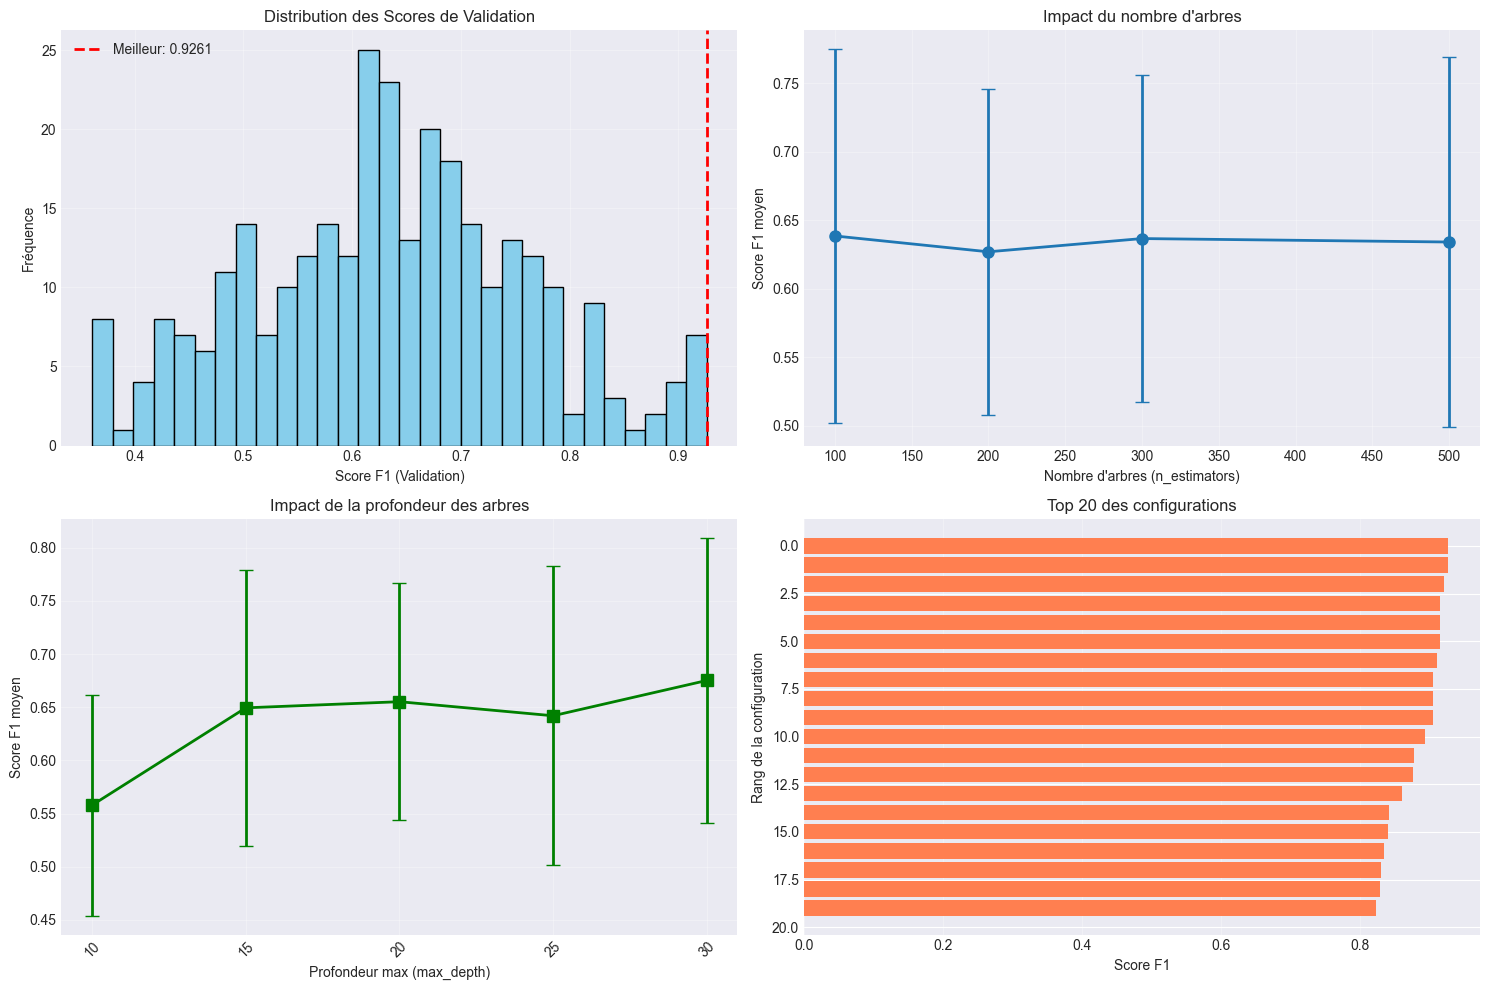


📊 Statistiques du tuning:
   - Meilleur score: 0.9261
   - Score moyen: 0.6338
   - Score médian: 0.6295
   - Écart-type: 0.1266


In [165]:
# Visualiser les résultats du tuning (si activé)
if enable_advanced_rf_tuning and 'rf_cv_results' in locals():
    print("📈 Analyse des résultats du tuning avancé\n")
    
    # Créer un DataFrame avec les résultats
    results_analysis = pd.DataFrame(rf_cv_results)
    
    # 1. Distribution des scores
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Score distribution
    axes[0, 0].hist(results_analysis['mean_test_score'], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(best_rf_score, color='red', linestyle='--', linewidth=2, label=f'Meilleur: {best_rf_score:.4f}')
    axes[0, 0].set_xlabel('Score F1 (Validation)')
    axes[0, 0].set_ylabel('Fréquence')
    axes[0, 0].set_title('Distribution des Scores de Validation')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Impact du nombre d'arbres
    if 'param_classifier__n_estimators' in results_analysis.columns:
        n_est_data = results_analysis.groupby('param_classifier__n_estimators')['mean_test_score'].agg(['mean', 'std'])
        axes[0, 1].errorbar(n_est_data.index, n_est_data['mean'], yerr=n_est_data['std'], 
                           marker='o', capsize=5, linewidth=2, markersize=8)
        axes[0, 1].set_xlabel('Nombre d\'arbres (n_estimators)')
        axes[0, 1].set_ylabel('Score F1 moyen')
        axes[0, 1].set_title('Impact du nombre d\'arbres')
        axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Impact de la profondeur
    if 'param_classifier__max_depth' in results_analysis.columns:
        depth_data = results_analysis.groupby('param_classifier__max_depth')['mean_test_score'].agg(['mean', 'std'])
        axes[1, 0].errorbar(range(len(depth_data)), depth_data['mean'], yerr=depth_data['std'],
                           marker='s', capsize=5, linewidth=2, markersize=8, color='green')
        axes[1, 0].set_xticks(range(len(depth_data)))
        axes[1, 0].set_xticklabels([str(x) if x is not None else 'None' for x in depth_data.index], rotation=45)
        axes[1, 0].set_xlabel('Profondeur max (max_depth)')
        axes[1, 0].set_ylabel('Score F1 moyen')
        axes[1, 0].set_title('Impact de la profondeur des arbres')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Top 20 configurations
    top_20 = results_analysis.nsmallest(20, 'rank_test_score')
    axes[1, 1].barh(range(20), top_20['mean_test_score'], color='coral')
    axes[1, 1].set_xlabel('Score F1')
    axes[1, 1].set_ylabel('Rang de la configuration')
    axes[1, 1].set_title('Top 20 des configurations')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les statistiques
    print(f"\n📊 Statistiques du tuning:")
    print(f"   - Meilleur score: {results_analysis['mean_test_score'].max():.4f}")
    print(f"   - Score moyen: {results_analysis['mean_test_score'].mean():.4f}")
    print(f"   - Score médian: {results_analysis['mean_test_score'].median():.4f}")
    print(f"   - Écart-type: {results_analysis['mean_test_score'].std():.4f}")
    
else:
    print("ℹ️ Activez enable_advanced_rf_tuning pour voir l'analyse des résultats")

## 5️⃣ Entraînement et Évaluation des Modèles

⚠️ **Important**: L'évaluation se fait sur le **set de test** (15%) qui n'a jamais été vu pendant l'entraînement ou le tuning !

In [166]:
def plot_confusion_matrix(model_name, cm):
    """Dessiner la matrice de confusion"""
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    plt.title(f'Matrice de Confusion - {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Réalité')
    plt.tight_layout()
    plt.show()

def evaluate_model_detailed(model, X_test, y_test, model_name):
    """Évaluation détaillée d'un modèle"""
    print(f"\n{'='*60}")
    print(f"Évaluation: {model_name}")
    print(f"{'='*60}")
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Rapport de classification
    print("\n📊 Rapport de classification:")
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n🔢 Matrice de confusion:")
    print(f"TP (VP): {cm[1][1]} | FP (FP): {cm[0][1]}")
    print(f"FN (FN): {cm[1][0]} | TN (VN): {cm[0][0]}")
    
    plot_confusion_matrix(model_name, cm)
    
    # Métriques
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    # Calculer AUC
    auc = "N/A"
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test)
            if proba.ndim == 2:
                auc = roc_auc_score(y_test, proba[:, 1])
            else:
                auc = roc_auc_score(y_test, proba)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            if getattr(scores, "ndim", 1) == 2:
                auc = roc_auc_score(y_test, scores[:, 1])
            else:
                auc = roc_auc_score(y_test, scores)
    except Exception:
        pass
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1-Score": f1,
        "AUC": auc
    }

print("✅ Fonction d'évaluation définie")

✅ Fonction d'évaluation définie



🚀 ENTRAÎNEMENT ET ÉVALUATION
📌 Entraînement: Train set (70%)
📌 Évaluation: Test set (15%) - Jamais vu !

🔄 Entraînement: Logistic Regression...

Évaluation: Logistic Regression

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       555
           1       0.62      0.23      0.34       107

    accuracy                           0.85       662
   macro avg       0.75      0.60      0.63       662
weighted avg       0.83      0.85      0.82       662


🔢 Matrice de confusion:
TP (VP): 25 | FP (FP): 15
FN (FN): 82 | TN (VN): 540


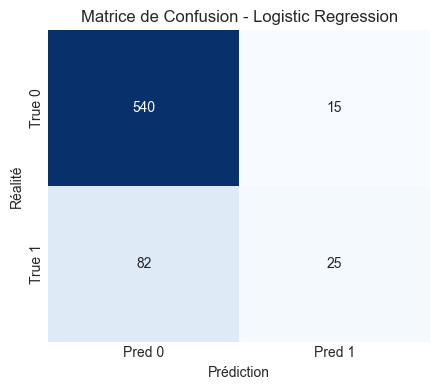


🔄 Entraînement: Perceptron...

Évaluation: Perceptron

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       555
           1       1.00      0.02      0.04       107

    accuracy                           0.84       662
   macro avg       0.92      0.51      0.48       662
weighted avg       0.87      0.84      0.77       662


🔢 Matrice de confusion:
TP (VP): 2 | FP (FP): 0
FN (FN): 105 | TN (VN): 555


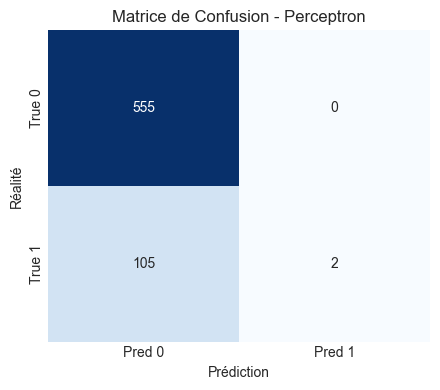


🔄 Entraînement: Decision Tree...

Évaluation: Decision Tree

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       555
           1       0.82      0.75      0.78       107

    accuracy                           0.93       662
   macro avg       0.88      0.86      0.87       662
weighted avg       0.93      0.93      0.93       662


🔢 Matrice de confusion:
TP (VP): 80 | FP (FP): 18
FN (FN): 27 | TN (VN): 537


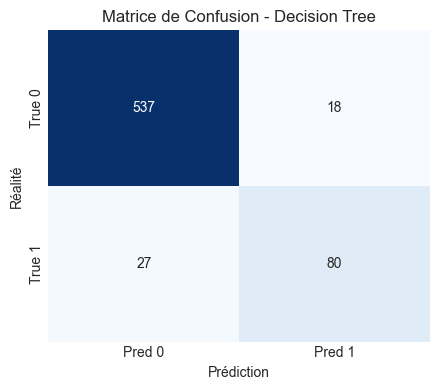


🔄 Entraînement: Random Forest...

Évaluation: Random Forest

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       555
           1       1.00      0.64      0.78       107

    accuracy                           0.94       662
   macro avg       0.97      0.82      0.88       662
weighted avg       0.95      0.94      0.94       662


🔢 Matrice de confusion:
TP (VP): 69 | FP (FP): 0
FN (FN): 38 | TN (VN): 555


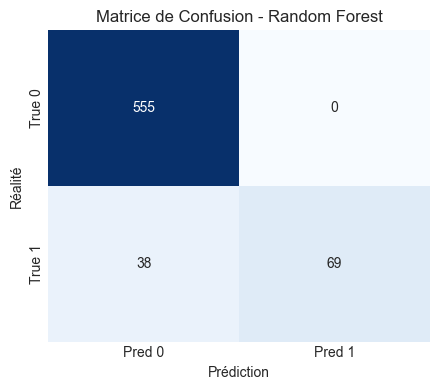


🔄 Entraînement: Support Vector Machine...

Évaluation: Support Vector Machine

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       555
           1       0.65      0.22      0.33       107

    accuracy                           0.85       662
   macro avg       0.76      0.60      0.63       662
weighted avg       0.83      0.85      0.82       662


🔢 Matrice de confusion:
TP (VP): 24 | FP (FP): 13
FN (FN): 83 | TN (VN): 542


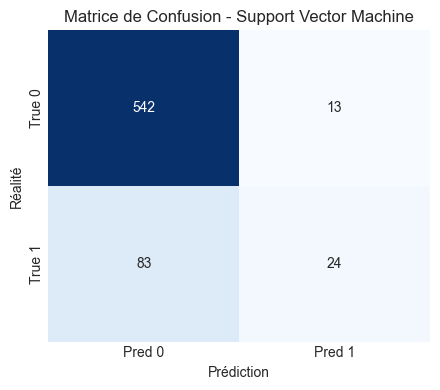


🔄 Entraînement: Naive Bayes...

Évaluation: Naive Bayes

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       555
           1       0.45      0.48      0.46       107

    accuracy                           0.82       662
   macro avg       0.67      0.68      0.68       662
weighted avg       0.83      0.82      0.82       662


🔢 Matrice de confusion:
TP (VP): 51 | FP (FP): 63
FN (FN): 56 | TN (VN): 492


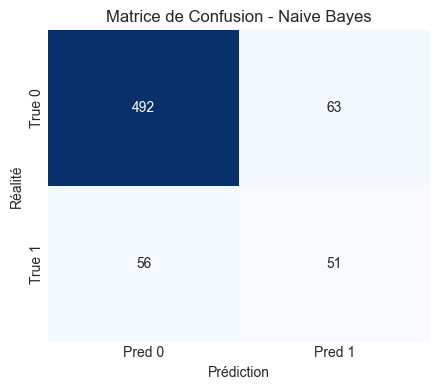


🔄 Entraînement: Random Forest (Advanced)...

Évaluation: Random Forest (Advanced)

📊 Rapport de classification:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       555
           1       1.00      0.88      0.94       107

    accuracy                           0.98       662
   macro avg       0.99      0.94      0.96       662
weighted avg       0.98      0.98      0.98       662


🔢 Matrice de confusion:
TP (VP): 94 | FP (FP): 0
FN (FN): 13 | TN (VN): 555


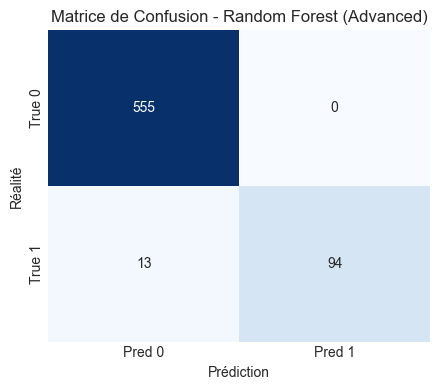


✅ ENTRAÎNEMENT ET ÉVALUATION TERMINÉS


In [167]:
# Entraîner et évaluer tous les modèles sur le TEST SET
print("\n" + "="*60)
print("🚀 ENTRAÎNEMENT ET ÉVALUATION")
print("="*60)
print("📌 Entraînement: Train set (70%)")
print("📌 Évaluation: Test set (15%) - Jamais vu !")
print("="*60)

trained_models = {}
results_summary = []

for name, pipeline in competitors.items():
    print(f"\n🔄 Entraînement: {name}...")
    
    # Entraîner sur le train set uniquement
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    # Évaluation détaillée sur le TEST SET (complètement séparé)
    metrics = evaluate_model_detailed(pipeline, X_test, y_test, name)
    results_summary.append(metrics)

print("\n" + "="*60)
print("✅ ENTRAÎNEMENT ET ÉVALUATION TERMINÉS")
print("="*60)

## 6️⃣ Comparaison des Modèles

In [168]:
# Table de comparaison
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\n" + "#"*60)
print("🏆 COMPARAISON DES MODÈLES")
print("#"*60 + "\n")

display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🥇 Meilleur modèle: {best_model_name}")


############################################################
🏆 COMPARAISON DES MODÈLES
############################################################



,Model,Accuracy,F1-Score,AUC
6,Random Forest (Advanced),0.980363,0.935323,0.996775
3,Random Forest,0.942598,0.784091,0.982184
2,Decision Tree,0.932024,0.780488,0.869016
5,Naive Bayes,0.820242,0.461538,0.754568
0,Logistic Regression,0.853474,0.340136,0.787876
4,Support Vector Machine,0.854985,0.333333,0.789475
1,Perceptron,0.841390,0.036697,0.755948



🥇 Meilleur modèle: Random Forest (Advanced)


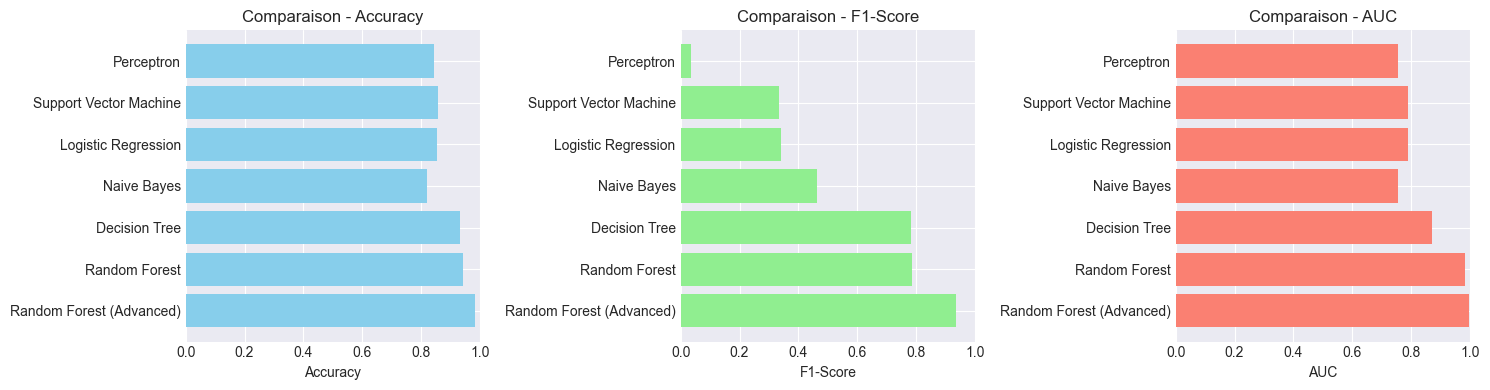

In [169]:
# Visualisation des performances
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparaison - Accuracy')
axes[0].set_xlim([0, 1])

# F1-Score
axes[1].barh(results_df['Model'], results_df['F1-Score'], color='lightgreen')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Comparaison - F1-Score')
axes[1].set_xlim([0, 1])

# AUC
auc_values = [v if isinstance(v, (int, float)) else 0 for v in results_df['AUC']]
axes[2].barh(results_df['Model'], auc_values, color='salmon')
axes[2].set_xlabel('AUC')
axes[2].set_title('Comparaison - AUC')
axes[2].set_xlim([0, 1])

plt.tight_layout()
plt.show()

## 7️⃣ Courbes ROC

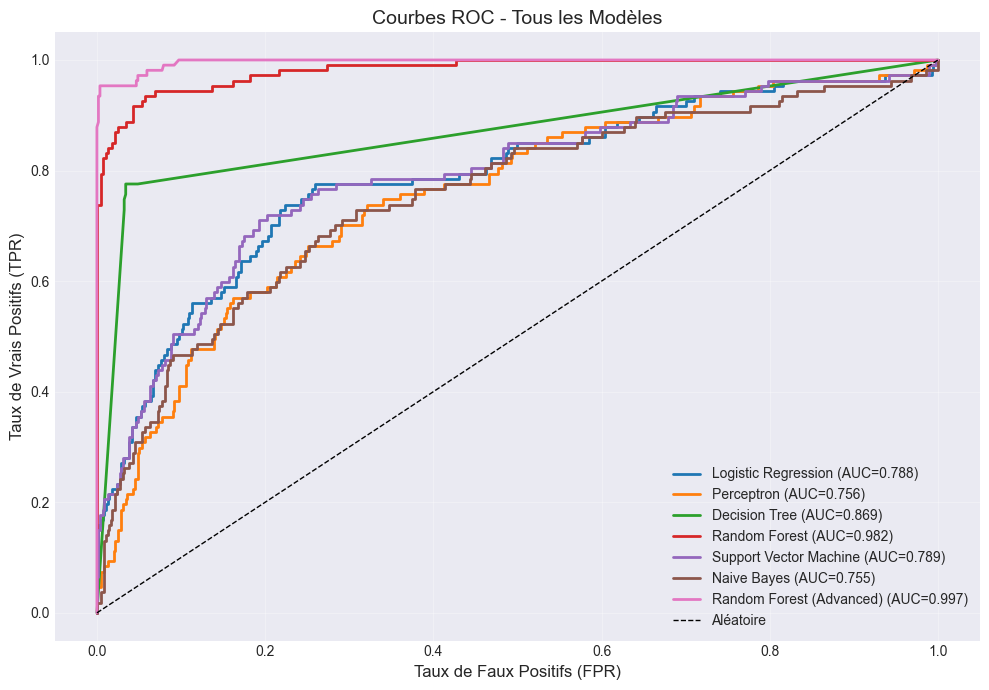

In [170]:
# Courbes ROC pour tous les modèles
plt.figure(figsize=(10, 7))

for name, pipeline in trained_models.items():
    try:
        if hasattr(pipeline, 'predict_proba'):
            proba = pipeline.predict_proba(X_test)
            scores = proba[:, 1] if proba.ndim == 2 else proba
        elif hasattr(pipeline, 'decision_function'):
            scores = pipeline.decision_function(X_test)
            if getattr(scores, 'ndim', 1) == 2:
                scores = scores[:, 1]
        else:
            continue

        fpr, tpr, _ = roc_curve(y_test, scores)
        auc_score = roc_auc_score(y_test, scores)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', linewidth=2)
    except Exception:
        continue

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire', linewidth=1)
plt.title('Courbes ROC - Tous les Modèles', fontsize=14)
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8️⃣ Courbes Précision-Rappel

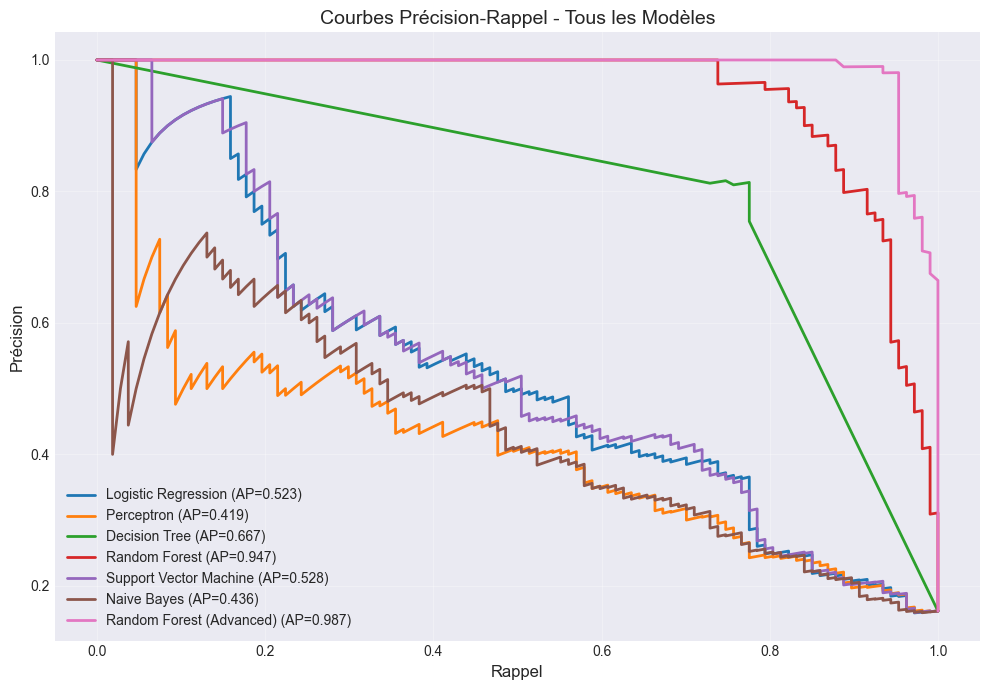

In [171]:
# Courbes Précision-Rappel pour tous les modèles
plt.figure(figsize=(10, 7))

for name, pipeline in trained_models.items():
    try:
        if hasattr(pipeline, 'predict_proba'):
            proba = pipeline.predict_proba(X_test)
            scores = proba[:, 1] if proba.ndim == 2 else proba
        elif hasattr(pipeline, 'decision_function'):
            scores = pipeline.decision_function(X_test)
            scores = scores[:, 1] if getattr(scores, 'ndim', 1) == 2 else scores
        else:
            continue
        
        precision, recall, _ = precision_recall_curve(y_test, scores)
        ap = average_precision_score(y_test, scores)
        plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)
    except Exception:
        continue

plt.title('Courbes Précision-Rappel - Tous les Modèles', fontsize=14)
plt.xlabel('Rappel', fontsize=12)
plt.ylabel('Précision', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9️⃣ Validation Croisée (5-Fold) - Optionnel

Cette validation se fait sur le **train set uniquement** pour évaluer la stabilité des modèles.

In [172]:
def cross_validate_models(competitors, X, y, n_splits=5):
    """Validation croisée stratifiée pour tous les modèles"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_summary = []
    
    print("\n" + "="*60)
    print(f"🔄 Validation Croisée {n_splits}-Fold")
    print("="*60 + "\n")
    
    for name, pipeline in competitors.items():
        print(f"Validation: {name}...")
        auc_scores, f1_scores, acc_scores, ap_scores = [], [], [], []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
            
            pipeline.fit(X_tr, y_tr)
            y_pred = pipeline.predict(X_te)
            
            acc_scores.append(accuracy_score(y_te, y_pred))
            f1_scores.append(f1_score(y_te, y_pred))
            
            # Calculer AUC et AP
            scores = None
            if hasattr(pipeline, 'predict_proba'):
                proba = pipeline.predict_proba(X_te)
                scores = proba[:, 1] if proba.ndim == 2 else proba
            elif hasattr(pipeline, 'decision_function'):
                scores = pipeline.decision_function(X_te)
                scores = scores[:, 1] if getattr(scores, 'ndim', 1) == 2 else scores
            
            if scores is not None:
                auc_scores.append(roc_auc_score(y_te, scores))
                ap_scores.append(average_precision_score(y_te, scores))
        
        cv_summary.append({
            'Model': name,
            'Acc(mean)': np.mean(acc_scores) if acc_scores else None,
            'F1(mean)': np.mean(f1_scores) if f1_scores else None,
            'AUC(mean)': np.mean(auc_scores) if auc_scores else None,
            'AP(mean)': np.mean(ap_scores) if ap_scores else None,
        })
    
    df = pd.DataFrame(cv_summary)
    print("\n" + "="*60)
    print("📊 Résultats de la Validation Croisée (moyennes)")
    print("="*60 + "\n")
    display(df)
    
    return df

# Exécuter la validation croisée
cv_results = cross_validate_models(competitors, X_train, y_train, n_splits=5)


🔄 Validation Croisée 5-Fold

Validation: Logistic Regression...
Validation: Perceptron...
Validation: Decision Tree...
Validation: Random Forest...
Validation: Support Vector Machine...
Validation: Naive Bayes...
Validation: Random Forest (Advanced)...

📊 Résultats de la Validation Croisée (moyennes)



,Model,Acc(mean),F1(mean),AUC(mean),AP(mean)
0,Logistic Regression,0.855848,0.336811,0.809799,0.523794
1,Perceptron,0.843217,0.080342,0.781398,0.468020
2,Decision Tree,0.898603,0.683865,0.805749,0.540290
3,Random Forest,0.920634,0.679750,0.965158,0.901037
4,Support Vector Machine,0.858114,0.335381,0.809670,0.515049
5,Naive Bayes,0.808554,0.434610,0.745449,0.383444
6,Random Forest (Advanced),0.958858,0.857087,0.982782,0.949369


## 🎯 Conclusion

Ce notebook a permis de :
1. ✅ Charger et prétraiter les données
2. ✅ Comparer 6 modèles de classification
3. ✅ Évaluer les performances avec plusieurs métriques
4. ✅ Visualiser les résultats avec ROC et PR curves
5. ✅ Valider avec cross-validation

Le meilleur modèle peut maintenant être utilisé pour la production !

## 🔟 Sauvegarde du Meilleur Modèle

Cette section permet de sauvegarder le modèle ayant obtenu les meilleures performances pour une utilisation future en production.

In [173]:
import joblib
import json
from datetime import datetime

# Identifier le meilleur modèle
print("🔍 Identification du meilleur modèle...\n")

# Récupérer le modèle avec le meilleur F1-Score
best_model_name = results_df.iloc[0]["Model"]
best_f1_score = results_df.iloc[0]["F1-Score"]
best_accuracy = results_df.iloc[0]["Accuracy"]
best_auc = results_df.iloc[0]["AUC"]

# Récupérer le pipeline du modèle
best_model = trained_models[best_model_name]

print(f"🏆 Meilleur modèle identifié:")
print(f"   - Nom: {best_model_name}")
print(f"   - F1-Score: {best_f1_score:.4f}")
print(f"   - Accuracy: {best_accuracy:.4f}")
print(f"   - AUC: {best_auc if isinstance(best_auc, str) else f'{best_auc:.4f}'}")

# Créer un dossier pour les modèles
models_dir = "saved_models"
import os
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"\n📁 Dossier '{models_dir}' créé")

# Timestamp pour le nom du fichier
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"{models_dir}/best_model_{timestamp}.joblib"
info_filename = f"{models_dir}/best_model_{timestamp}_info.json"

print(f"\n💾 Sauvegarde du modèle...")

🔍 Identification du meilleur modèle...

🏆 Meilleur modèle identifié:
   - Nom: Random Forest (Advanced)
   - F1-Score: 0.9353
   - Accuracy: 0.9804
   - AUC: 0.9968

💾 Sauvegarde du modèle...


In [174]:
# Sauvegarder le modèle avec joblib
joblib.dump(best_model, model_filename)
print(f"✅ Modèle sauvegardé: {model_filename}")

# Préparer les informations du modèle
model_info = {
    "model_name": best_model_name,
    "timestamp": timestamp,
    "date_training": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "performance": {
        "f1_score": float(best_f1_score),
        "accuracy": float(best_accuracy),
        "auc": float(best_auc) if isinstance(best_auc, (int, float)) else best_auc
    },
    "dataset": {
        "train_size": len(X_train),
        "validation_size": len(X_val),
        "test_size": len(X_test),
        "split_ratio": "70/15/15"
    },
    "hyperparameters": {}
}

# Ajouter les hyperparamètres si disponibles
if enable_tuning and best_model_name in tuning_results:
    best_params, _ = tuning_results[best_model_name]
    model_info["hyperparameters"] = best_params
elif enable_advanced_rf_tuning and best_model_name == "Random Forest (Advanced)":
    model_info["hyperparameters"] = best_rf_params

# Sauvegarder les métadonnées en JSON
with open(info_filename, 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=4, ensure_ascii=False)

print(f"✅ Métadonnées sauvegardées: {info_filename}")

print(f"\n📊 Résumé de la sauvegarde:")
print(f"   - Fichier modèle: {model_filename}")
print(f"   - Fichier métadonnées: {info_filename}")
print(f"   - Taille du modèle: {os.path.getsize(model_filename) / (1024*1024):.2f} MB")

# Afficher les métadonnées
print(f"\n📋 Métadonnées du modèle:")
display(pd.DataFrame([model_info["performance"]]).T.rename(columns={0: "Valeur"}))

✅ Modèle sauvegardé: saved_models/best_model_20251217_095208.joblib
✅ Métadonnées sauvegardées: saved_models/best_model_20251217_095208_info.json

📊 Résumé de la sauvegarde:
   - Fichier modèle: saved_models/best_model_20251217_095208.joblib
   - Fichier métadonnées: saved_models/best_model_20251217_095208_info.json
   - Taille du modèle: 21.26 MB

📋 Métadonnées du modèle:


,Valeur
f1_score,0.935323
accuracy,0.980363
auc,0.996775


### 📥 Test de Rechargement du Modèle

Vérifions que le modèle peut être rechargé correctement.

In [175]:
# Recharger le modèle et les métadonnées
print("🔄 Test de rechargement du modèle...\n")

# Charger le modèle
loaded_model = joblib.load(model_filename)
print(f"✅ Modèle rechargé depuis: {model_filename}")

# Charger les métadonnées
with open(info_filename, 'r', encoding='utf-8') as f:
    loaded_info = json.load(f)

print(f"✅ Métadonnées rechargées depuis: {info_filename}")

# Vérifier que le modèle fonctionne
print(f"\n🧪 Test de prédiction sur quelques exemples du test set...")

# Prendre 5 exemples du test set
sample_indices = list(range(5))
X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]

# Faire des prédictions
predictions = loaded_model.predict(X_sample)
probabilities = loaded_model.predict_proba(X_sample)[:, 1]

# Afficher les résultats
print(f"\n📊 Résultats du test:")
test_results = pd.DataFrame({
    'Index': sample_indices,
    'Réalité': y_sample.values,
    'Prédiction': predictions,
    'Probabilité Départ': [f"{p:.2%}" for p in probabilities],
    'Statut': ['✅ Correct' if predictions[i] == y_sample.iloc[i] else '❌ Incorrect' 
               for i in range(len(predictions))]
})

display(test_results)

# Calculer l'exactitude sur l'échantillon
correct_predictions = (predictions == y_sample.values).sum()
print(f"\n✅ Précision sur l'échantillon: {correct_predictions}/{len(predictions)} ({correct_predictions/len(predictions):.1%})")

print(f"\n🎉 Le modèle a été sauvegardé et rechargé avec succès !")

🔄 Test de rechargement du modèle...

✅ Modèle rechargé depuis: saved_models/best_model_20251217_095208.joblib
✅ Métadonnées rechargées depuis: saved_models/best_model_20251217_095208_info.json

🧪 Test de prédiction sur quelques exemples du test set...

📊 Résultats du test:


,Index,Réalité,Prédiction,Probabilité Départ,Statut
0,0,0,0,14.00%,✅ Correct
1,1,1,1,67.20%,✅ Correct
2,2,0,0,2.61%,✅ Correct
3,3,0,0,5.60%,✅ Correct
4,4,0,0,1.60%,✅ Correct



✅ Précision sur l'échantillon: 5/5 (100.0%)

🎉 Le modèle a été sauvegardé et rechargé avec succès !
